# Tutorial 2 - Spatial Network analysis

**Lesson objectives**

This tutorial focuses on **spatial networks** and learn how to construct a routable **directed** graph for Networkx and find shortest paths along the given street network based on travel times or distance by car. In addition, we will learn how to calculate travel times matrices by public transport using the `cafein` library. 

## Tutorial

In this tutorial we will focus on a network analysis methods that relate to way-finding.
Finding a shortest path from A to B using a specific street network is a very common spatial analytics
problem that has many practical applications.

Python provides easy to use tools for conducting spatial network analysis.
One of the easiest ways to start is to use a library
called [Networkx](https://networkx.github.io/documentation/stable/)
which is a Python module that provides a lot tools that can be used to
analyze networks on various different ways. It also contains algorithms
such as [Dijkstra’s
algorithm](https://networkx.github.io/documentation/networkx-1.10/reference/generated/networkx.algorithms.shortest_paths.weighted.single_source_dijkstra.html#networkx.algorithms.shortest_paths.weighted.single_source_dijkstra)
or [A\*](https://networkx.github.io/documentation/networkx-1.10/reference/generated/networkx.algorithms.shortest_paths.astar.astar_path.html#networkx.algorithms.shortest_paths.astar.astar_path)
algoritm that are commonly used to find shortest paths along
transportation network.

Next, we will learn how to do spatial network analysis in practice.

## Materials

In case you want to run the tutorial on your own computer, you can download this Notebook and related data from here:

- [Download materials](https://drive.google.com/uc?export=download&id=133LS2DJlN8mKypK6XY9Vw2ZXUd5mAZOP) (93 MB)
- See [Installation instructions](https://sumogis.readthedocs.io/en/latest/course-info/installing-miniconda.html) to install the Python libraries needed for running this tutorial.


## Typical workflow for routing

If you want to conduct network analysis (in any programming language) there are a few basic steps that typically needs to be done before you can start routing. These steps are:

 1. **Retrieve data** (such as street network from OSM or Digiroad + possibly transit data if routing with PT).
 2. **Modify the network** by adding/calculating edge weights (such as travel times based on speed limit and length of the road segment).
 3. **Build a routable graph** for the routing tool that you are using (e.g. for NetworkX, igraph or OpenTripPlanner).
 4. **Conduct network analysis** (such as shortest path analysis) with the routing tool of your choice. 

## 1. Retrieve data

As a first step, we need to obtain data for routing. [Pyrosm](https://pyrosm.readthedocs.io/en/latest/) library makes it really easy to retrieve routable networks from OpenStreetMap (OSM) with different transport modes (walking, cycling and driving). 

- Let's first extract OSM data for Helsinki that are walkable. In `pyrosm`, we can use a function called `osm.get_network()` which retrieves data from OpenStreetMap. It is possible to specify what kind of roads should be retrieved from OSM with `network_type` -parameter (supports `walking`, `cycling`, `driving`). 


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

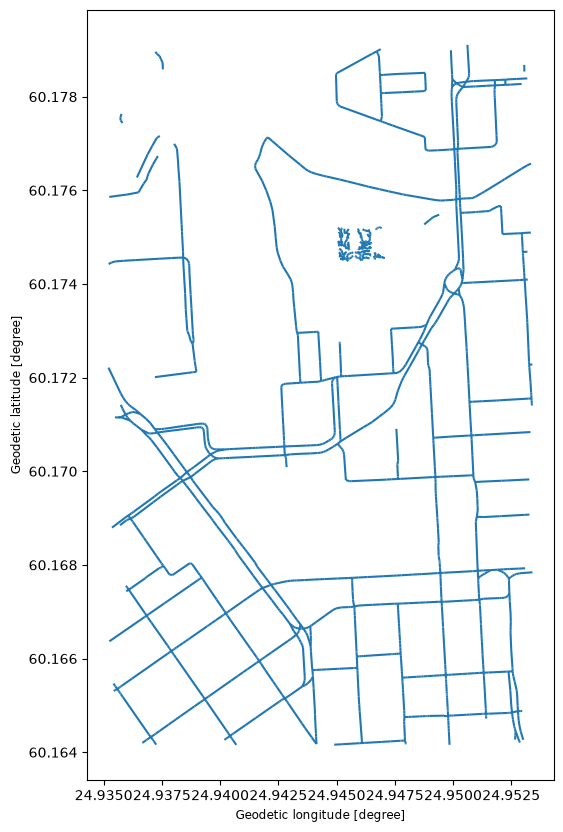

In [1]:
from pyrosm import OSM, get_data
import geopandas as gpd
import pandas as pd
import networkx as nx

# We will use test data for Helsinki that comes with pyrosm
osm = OSM(get_data("helsinki_pbf"))

# Parse roads that can be driven by car
roads = osm.get_network(network_type="driving")
roads.plot(figsize=(10,10))

In [2]:
roads

,bicycle,bridge,cycleway,highway,int_ref,lanes,lit,maxspeed,motor_vehicle,name,...,surface,tunnel,width,id,timestamp,version,tags,osm_type,geometry,length
0,NaN,NaN,NaN,unclassified,NaN,2,yes,30,NaN,Erottajankatu,...,paved,NaN,NaN,4236349,1380031970,21,"{""visible"":false,""name:fi"":""Erottajankatu"",""na...",way,"MULTILINESTRING ((24.94327 60.16651, 24.94337 ...",14.0
1,NaN,NaN,NaN,unclassified,NaN,2,yes,30,NaN,Korkeavuorenkatu,...,paved,NaN,NaN,4243035,1543430213,12,"{""visible"":false,""name:fi"":""Korkeavuorenkatu"",...",way,"MULTILINESTRING ((24.94567 60.16767, 24.94567 ...",51.0
2,NaN,NaN,NaN,residential,NaN,2,NaN,30,NaN,Fabianinkatu,...,cobblestone,NaN,NaN,4243036,1543430213,21,"{""visible"":false,""hazmat:A"":""destination"",""nam...",way,"MULTILINESTRING ((24.94944 60.16791, 24.94946 ...",86.0
3,NaN,NaN,NaN,unclassified,NaN,NaN,yes,30,NaN,Yliopistonkatu,...,asphalt,NaN,NaN,4247500,1545207617,16,"{""visible"":false,""name:fi"":""Yliopistonkatu"",""n...",way,"MULTILINESTRING ((24.9454 60.16981, 24.94555 6...",14.0
4,NaN,NaN,NaN,secondary,NaN,2,yes,40,NaN,Vilhonkatu,...,cobblestone,NaN,NaN,4247501,1549629388,25,"{""visible"":false,""embedded_rails"":""tram"",""name...",way,"MULTILINESTRING ((24.94745 60.17209, 24.9473 6...",13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,NaN,NaN,NaN,unclassified,NaN,1,yes,40,NaN,Mikonkatu,...,paved,NaN,NaN,655097817,1544822413,1,"{""visible"":false,""name:fi"":""Mikonkatu"",""name:s...",way,"MULTILINESTRING ((24.94508 60.17149, 24.94507 ...",13.0
880,NaN,NaN,NaN,unclassified,NaN,1,yes,40,NaN,Mikonkatu,...,paved,NaN,NaN,655097818,1544822413,1,"{""visible"":false,""name:fi"":""Mikonkatu"",""name:s...",way,"MULTILINESTRING ((24.94512 60.17108, 24.94509 ...",38.0
881,use_sidepath,NaN,NaN,primary_link,NaN,1,yes,30,NaN,Bulevardi,...,paved,NaN,NaN,655405463,1544973201,1,"{""visible"":false,""loc_name"":""Bule;Bulis;Bulsa;...",way,"MULTILINESTRING ((24.94342 60.16664, 24.94344 ...",10.0
882,NaN,NaN,NaN,primary_link,NaN,2,yes,30,NaN,NaN,...,paved,NaN,NaN,655405465,1544973201,1,"{""visible"":false,""guideposted_leads_to_ref"":""4...",way,"MULTILINESTRING ((24.94342 60.16664, 24.9435 6...",9.0


Okay, now we have drivable roads as a GeoDataFrame for the city center of Helsinki. If you look at the GeoDataFrame (scroll to the right), we can see that `pyrosm` has also calculated us the `length` of each road segment (presented in meters). The geometries are presented here as `MultiLineString` objects. From the map above we can see that the data also includes short pieces of roads that do not lead to anywhere (i.e. they are *isolated*). This is a typical issue when working with real-world data such as roads. Hence, at some point we need to take care of those in someway (remove them (typical solution), or connect them to other parts of the network). 

In OSM, the information about the allowed direction of movement is stored in column `oneway`. Let's take a look what kind of values we have in that column:

In [3]:
roads["oneway"].unique()

<ArrowStringArray>
['yes', nan, 'no']
Length: 3, dtype: str

As we can see the unique values in that column are `"yes"`, `"no"` or `None`. We can use this information to construct a `directed` graph for routing by car. For walking and cycling, you typically want create a `bidirectional` graph, because the travel is typically allowed in both directions at least in Finland. Notice, that the rules vary by country, e.g. in Copenhagen you have oneway rules also for bikes but typically each road have the possibility to travel both directions (you just need to change the side of the road if you want to make a U-turn). Column `maxspeed` contains information about the speed limit for given road:

In [4]:
roads["maxspeed"].unique()

<ArrowStringArray>
['30', '40', nan]
Length: 3, dtype: str

As we can see, there are also `None` values in the data, meaning that the speed limit has not been tagged for some roads. This is typical, and often you need to fill the non existing speed limits yourself. This can be done by taking advantage of the road class that is always present in column `highway`:

In [5]:
roads["highway"].unique()

<ArrowStringArray>
[ 'unclassified',   'residential',     'secondary',      'tertiary',
       'primary',  'primary_link', 'tertiary_link',         'trail']
Length: 8, dtype: str

Based on these values, we can make assumptions that e.g. `residential` roads in Helsinki have a speed limit of 30 kmph. Hence, this information can be used to fill the missing values in `maxspeed`. As we can see, the current version of the `pyrosm` tool seem to have a bug because some non-drivable roads were also leaked to our network (e.g. `footway`, `cycleway`). If you notice these kind of issues with any of the libraries that you use, please notify the developers by raising an Issue in GitHub. This way, you can help improving the software. For this given problem, an [issue has already been raised](https://github.com/HTenkanen/pyrosm/issues/108) so you don't need to do it again (it's always good to check if a related issue exists in GitHub before adding a new one).  

Okay, but how can we make a routable graph out of this data of ours? Let's remind us about the basic elements of a graph that we went through in the lecture slides:

![Basic elements of a graph](img/graph_elements.png)

So to be able to create a graph we need to have **nodes** and **edges**. Now we have a GeoDataFrame of edges, but where are those nodes? Well they are not yet anywhere, but with `pyrosm` we can easily retrieve the nodes as well by specifying `nodes=True`, when parsing the streets:

(60.17, 60.173)

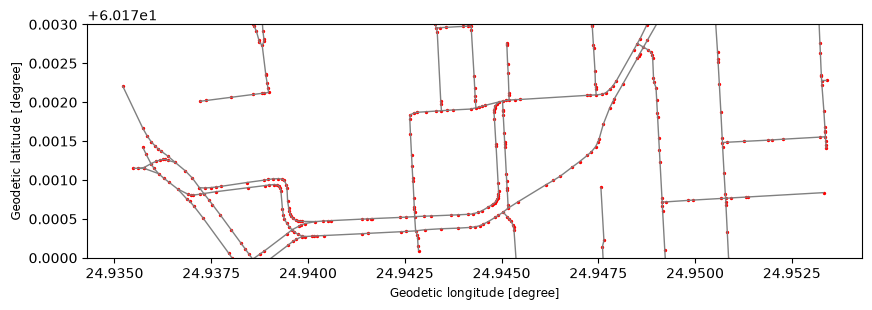

In [6]:
# Parse nodes and edges
nodes, edges = osm.get_network(network_type="driving", nodes=True)

# Plot the data
ax = edges.plot(figsize=(10,10), color="gray", lw=1.0)
ax = nodes.plot(ax=ax, color="red", markersize=2)

# Zoom in to take a closer look
#ax.set_xlim([24.9375, 24.945])
ax.set_ylim([60.17, 60.173])

In [7]:
edges.head()

,bicycle,bridge,cycleway,highway,int_ref,lanes,lit,maxspeed,motor_vehicle,name,...,width,id,timestamp,version,tags,osm_type,geometry,u,v,length
0,NaN,NaN,NaN,unclassified,NaN,2,yes,30,NaN,Erottajankatu,...,NaN,4236349,1380031970,21,"{""visible"":false,""name:fi"":""Erottajankatu"",""na...",way,"LINESTRING (24.94327 60.16651, 24.94337 60.16644)",1372477605,292727220,9.370
1,NaN,NaN,NaN,unclassified,NaN,2,yes,30,NaN,Erottajankatu,...,NaN,4236349,1380031970,21,"{""visible"":false,""name:fi"":""Erottajankatu"",""na...",way,"LINESTRING (24.94337 60.16644, 24.9434 60.16641)",292727220,2394117042,4.499
2,NaN,NaN,NaN,unclassified,NaN,2,yes,30,NaN,Korkeavuorenkatu,...,NaN,4243035,1543430213,12,"{""visible"":false,""name:fi"":""Korkeavuorenkatu"",...",way,"LINESTRING (24.94567 60.16767, 24.94567 60.16763)",296250563,2049084195,4.174
3,NaN,NaN,NaN,unclassified,NaN,2,yes,30,NaN,Korkeavuorenkatu,...,NaN,4243035,1543430213,12,"{""visible"":false,""name:fi"":""Korkeavuorenkatu"",...",way,"LINESTRING (24.94567 60.16763, 24.94569 60.16744)",2049084195,60072359,21.692
4,NaN,NaN,NaN,unclassified,NaN,2,yes,30,NaN,Korkeavuorenkatu,...,NaN,4243035,1543430213,12,"{""visible"":false,""name:fi"":""Korkeavuorenkatu"",...",way,"LINESTRING (24.94569 60.16744, 24.94571 60.16726)",60072359,6100704327,19.083


Okay, as we can see now we have both the roads (i.e. *edges*) and the nodes that connect the street elements together (in red) that are typically intersections. However, we can see that many of the nodes are in locations that are clearly not intersections. This is intented behavior to ensure that we have full **connectivity** in our network. We can at later stage clean and simplify this network by merging all roads that belong to the same link (i.e. street elements that are between two intersections) which also reduces the size of the network. 

```{note} 

In OSM, the street topology is typically not directly suitable for graph traversal due to missing nodes at intersections which means that the roads are not splitted at those locations. The consequence of this, is that it is not possible to make a turn if there is no intersection present in the data structure. Hence, `pyrosm` will separate all road segments/geometries into individual rows in the data. 
```

Let's take a look what our nodes data look like:

In [8]:
nodes.head()

,tags,version,lat,changeset,timestamp,visible,lon,id,geometry
0,None,2,60.166514,0,1390926206,False,24.943271,1372477605,POINT (24.94327 60.16651)
1,"{'highway': 'crossing', 'crossing': 'traffic_s...",6,60.166444,0,1383915357,False,24.943365,292727220,POINT (24.94337 60.16644)
2,None,1,60.166408,0,1374595731,False,24.943403,2394117042,POINT (24.9434 60.16641)
3,"{'highway': 'crossing', 'crossing': 'uncontrol...",5,60.167668,0,1290714658,False,24.945668,296250563,POINT (24.94567 60.16767)
4,{'traffic_calming': 'divider'},1,60.167630,0,1354578076,False,24.945671,2049084195,POINT (24.94567 60.16763)


As we can see, the `nodes` GeoDataFrame contains information about the coordinates of each node as well as a unique `id` for each node. These `id` values are used to determine the connectivity in our network. Hence, `pyrosm` has also added two columns to the `edges` GeoDataFrame that specify **from** and **to** ids for each edge. Column `u` contains information about the **from-id** and column `v` about the **to-id** accordingly:

In [9]:
# Check last four columns
edges.iloc[:5,-4:]

,geometry,u,v,length
0,"LINESTRING (24.94327 60.16651, 24.94337 60.16644)",1372477605,292727220,9.370
1,"LINESTRING (24.94337 60.16644, 24.9434 60.16641)",292727220,2394117042,4.499
2,"LINESTRING (24.94567 60.16767, 24.94567 60.16763)",296250563,2049084195,4.174
3,"LINESTRING (24.94567 60.16763, 24.94569 60.16744)",2049084195,60072359,21.692
4,"LINESTRING (24.94569 60.16744, 24.94571 60.16726)",60072359,6100704327,19.083


We can see that the geometries are now stored as `LineString` instead of `MultiLineString`. At this point, we can fix the issue related to having some pedestrian roads in our network. We can do this by removing all edges from out GeoDataFrame that have `highway` value in `'cycleway', 'footway', 'pedestrian', 'trail', 'crossing'`:

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

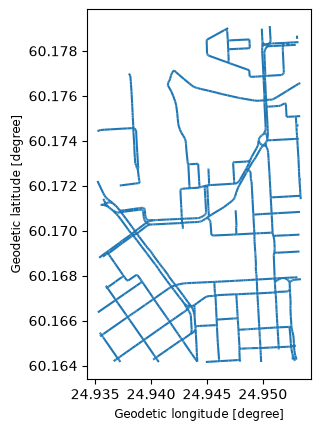

In [10]:
edges = edges.loc[~edges["highway"].isin(['cycleway', 'footway', 'pedestrian', 'trail', 'crossing'])].copy()
edges.plot()

Now we can see, that some of the isolated edges were removed from the data. The character `~` (tilde) in the command above is a *negation* operator that is handy if you want to e.g. remove some rows from your GeoDataFrame based on criteria such as we used here.  

## 2. Modify the data

At this stage, we have the necessary components to build a routable graph (nodes and edges) based on distance. However, in real life the network distance is not the best cost metric to use, because the shortest path (based on distance) is not necessarily always the optimal route in terms of **travel time**. Time is typically the measure that people value more (plus it is easier to comprehend), so at this stage we want to **add a new cost attribute** to our edges GeoDataFrame that converts the metric distance information to travel time (in seconds) based on following formula:

 - `<distance-in-meters> / (<speed-limit-kmph> / 3.6)`
 
Before we can do this calculation, we need to ensure that all rows in `maxspeed` column have information about the speed limit. Let's check the value counts of the column and also include information about the `NaN` values with `dropna` parameter:

In [11]:
# Count values
edges["maxspeed"].value_counts(dropna=False)

maxspeed
30     1076
40      422
NaN       2
Name: count, dtype: int64

As we can see, the rows which do not contain information about the speed limit is the second largest group in our data. Hence, we need to apply a criteria to fill these gaps. We can do this based on following "rule of thumb" criteria in Finland (notice that these vary country by country):

| Road class           | Speed limit within urban region | Speed limit outside urban region |
|----------------------|---------------------------------|----------------------------------|
| motorway             | 100                             | 120                              |
| motorway_link        | 80                              | 80                               |
| trunk                | 60                              | 100                              |
| trunk_link           | 60                              | 60                               |
| primary              | 50                              | 80                               |
| primary_link         | 50                              | 50                               |
| secondary            | 50                              | 50                               |
| secondary_link       | 50                              | 50                               |
| tertiary             | 50                              | 60                               |
| tertiary_link        | 50                              | 50                               |
| unclassified         | 50                              | 80                               |
| unclassified_link    | 50                              | 50                               |
| residential          | 50                              | 80                               |
| living_street        | 20                              | NA                               |
| service              | 30                              | NA                               |
| other                | 50                              | 80                               |

For simplicity, we can consider that all the roads in Helsinki Region follows the *within urban region* speed limits, although this is not exactly true (the higher speed limits start somewhere at the outer parts of the city region). For making the speed limit values more robust / correct, you could use data about urban/rural classification which is available in Finland from [Finnish Environment Institute](https://www.avoindata.fi/data/fi/dataset/kaupunki-maaseutu-luokitus-ykr). Let's first convert our `maxspeed` values to integers using `astype()` method:

In [12]:
edges["maxspeed"] = edges["maxspeed"].astype(float).astype(pd.Int64Dtype())
edges["maxspeed"].unique()

<IntegerArray>
[30, 40, <NA>]
Length: 3, dtype: Int64

As we can see, now the maxspeed values are stored in integer format inside an `IntegerArray`, and the `None` values were converted into `pandas.NA` objects that are assigned with `<NA>`. Now we can create a function that returns a numeric value for different road classes based on the criteria in the table above:

In [13]:
def road_class_to_kmph(road_class):
    """
    Returns a speed limit value based on road class, 
    using typical Finnish speed limit values within urban regions.
    """
    if road_class == "motorway":
        return 100
    elif road_class == "motorway_link":
        return 80
    elif road_class in ["trunk", "trunk_link"]:
        return 60
    elif road_class == "service":
        return 30
    elif road_class == "living_street":
        return 20
    else:
        return 50

Now we can apply this function to all rows that **do not have speed limit information**:

In [14]:
mask = edges["maxspeed"].isnull()

In [15]:
mask

0       False
1       False
2       False
3       False
4       False
        ...  
1921    False
1922    False
1923    False
1924    False
1925    False
Name: maxspeed, Length: 1500, dtype: bool

In [16]:
# Separate rows with / without speed limit information 
mask = edges["maxspeed"].isnull()
edges_without_maxspeed = edges.loc[mask].copy()
edges_with_maxspeed = edges.loc[~mask].copy()

# Apply the function and update the maxspeed
edges_without_maxspeed["maxspeed"] = edges_without_maxspeed["highway"].apply(road_class_to_kmph)
edges_without_maxspeed.head(5).loc[:, ["maxspeed", "highway"]]

,maxspeed,highway
1141,50,unclassified
1142,50,unclassified


Okay, as we can see now the `maxspeed` value have been updated according our criteria, and e.g. the `service` road class have been given the speed limit 30 kmph. Now we can recreate the edges GeoDataFrame by combining the two frames: 

In [17]:
edges = pd.concat([edges_with_maxspeed, edges_without_maxspeed])
#edges = edges_with_maxspeed.append(edges_without_maxspeed)
edges["maxspeed"].unique()

<IntegerArray>
[30, 40, 50]
Length: 3, dtype: Int64

Great, now all of our edges have information about the speed limit. We can also visualize them:

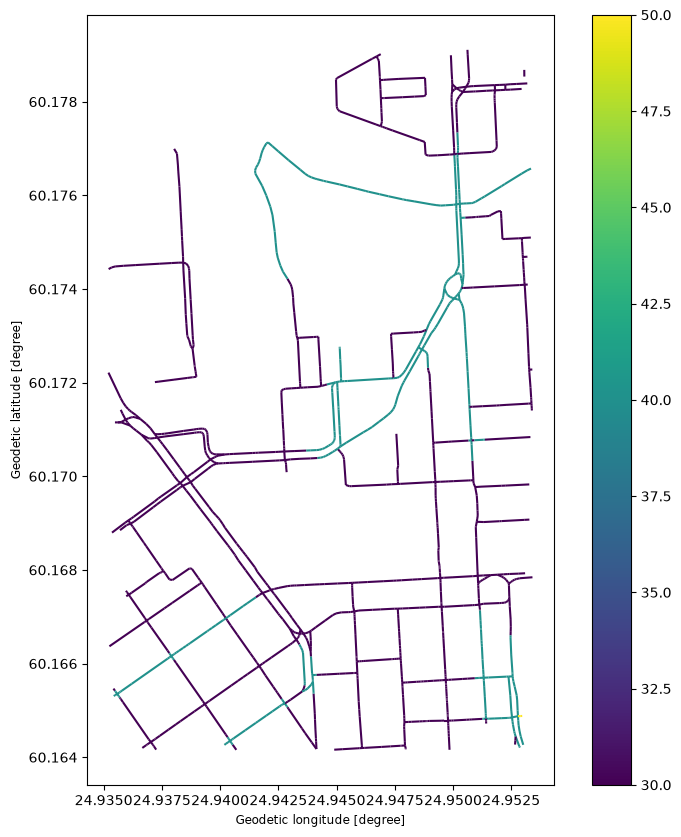

In [18]:
# Convert the value into regular integer Series (the plotting requires having Series instead of IntegerArray) 
edges["maxspeed"] = edges["maxspeed"].astype(int)
ax = edges.plot(column="maxspeed", figsize=(10,10), legend=True)

Finally, we can calculate the travel time in seconds using the formula we saw earlier and add that as a new cost attribute for our network:

In [19]:
edges["travel_time_seconds"] = edges["length"] / (edges["maxspeed"]/3.6)
edges.iloc[0:10, -4:]

,u,v,length,travel_time_seconds
0,1372477605,292727220,9.370,1.12440
1,292727220,2394117042,4.499,0.53988
2,296250563,2049084195,4.174,0.50088
3,2049084195,60072359,21.692,2.60304
4,60072359,6100704327,19.083,2.28996
5,6100704327,296250223,6.027,0.72324
6,264015226,25345665,9.644,1.15728
7,25345665,296248024,7.016,0.84192
8,296248024,426911766,4.137,0.49644
9,426911766,60072364,21.132,2.53584


Excellent! Now our GeoDataFrame has all the information we need for creating a graph that can be used to conduct shortest path analysis based on length or travel time. Notice that here we assume that the cars can drive with the same speed as what the speed limit is. Considering the urban dynamics and traffic congestion, this assumption might not hold, but for simplicity, we assume so in this tutorial. 

## 3. Build a directed graph with pyrosm

We can use `pyrosm` library (as well as `OSMnx`) to easily build a directed graph. Let's see how we can create a routable NetworkX graph using `pyrosm` with one command:

In [20]:
G = osm.to_graph(nodes, edges, graph_type="networkx")
G

Now we have a similar routable graph, but `pyrosm` actually does some additional steps in the background. By default, `pyrosm` cleans all **unconnected** edges from the graph and only keeps edges that can be reached from every part of the network. In addition, `pyrosm` automatically modifies the graph attribute information in a way that they are compatible with `OSMnx` that provides many handy functionalities to work with graphs. Such as converting the graph back into GeoDataFrames, which we can plot on an interactive map:

In [21]:
import osmnx as ox

# Convert the graph edges into a GeoDataFrame and plot them on an interactive map
ox.graph_to_gdfs(G, nodes=False).explore()

## 4. Routing with NetworkX

Now we have everything we need to start routing with NetworkX (based on driving distance or travel time). But first, let's again go through some basics about routing.

### Basic logic in routing

Most (if not all) routing algorithms work more or less in a similar manner. The basic steps for finding an optimal route from A to B, is to:
 1. Find the nearest node for origin location \* (+ get info about its node-id and distance between origin and node)
 2. Find the nearest node for destination location \* (+ get info about its node-id and distance between origin and node)
 3. Use a routing algorithm to find the shortest path between A and B
 4. Retrieve edge attributes for the given route(s) and summarize them (can be distance, time, CO2, or whatever)
 
\* in more advanced implementations you might search for the closest edge

This same logic should be applied always when searching for an optimal route between a single origin to a single destination, or when calculating one-to-many -type of routing queries (producing e.g. travel time matrices). 

## Find the optimal route between two locations

Next, we will learn how to find the shortest path between two locations using [Dijkstra's](https://en.wikipedia.org/wiki/Dijkstra%27s_algorithm) algorithm.

First, let's find the closest nodes for two locations that are located in the area. OSMnx provides a handly function for geocoding an address `ox.geocode()`. We can use that to retrieve the x and y coordinates of our origin and destination.

In [22]:
# OSM data is in WGS84 so typically we need to use lat/lon coordinates when searching for the closest node

# Origin
orig_address = "Simonkatu 3, Helsinki"
orig_y, orig_x = ox.geocode(orig_address)  # notice the coordinate order (y, x)!

# Destination
dest_address = "Unioninkatu 33, Helsinki"
dest_y, dest_x = ox.geocode(dest_address) 

print("Origin coords:", orig_x, orig_y)
print("Destination coords:", dest_x, dest_y)

Origin coords: 24.9367234 60.1691873
Destination coords: 24.9510728 60.1722121


Okay, now we have coordinates for our origin and destination.

### Find the nearest nodes

Next, we need to find the closest nodes from the graph for both of our locations. For calculating the closest point we use `ox.distance.nearest_nodes()` -function and specify `return_dist=True` to get the distance in meters.

In [23]:
# 1. Find the closest nodes for origin and destination
orig_node_id, dist_to_orig = ox.distance.nearest_nodes(G, X=orig_x, Y=orig_y, return_dist=True)
dest_node_id, dist_to_dest = ox.distance.nearest_nodes(G, X=dest_x, Y=dest_y, return_dist=True)

print("Origin node-id:", orig_node_id, "and distance:", dist_to_orig, "meters.")
print("Destination node-id:", dest_node_id, "and distance:", dist_to_dest, "meters.")

Origin node-id: 3236096605 and distance: 27.980277801537195 meters.
Destination node-id: 1012307791 and distance: 24.745369987684445 meters.


Now we are ready to start the actual routing with NetworkX. 

### Find the fastest route by distance / time

Now we can do the routing and find the shortest path between the origin and target locations
by using the `dijkstra_path()` function of NetworkX. For getting only the cumulative cost of the trip, we can directly use a function `dijkstra_path_length()` that returns the travel time without the actual path. 

With `weight` -parameter we can specify the attribute that we want to use as cost/impedance. We have now three possible weight attributes available: `'length'` and `'travel_time_seconds'`.    

- Let's first calculate the routes between locations by walking and cycling, and also retrieve the travel times

In [24]:
# Calculate the paths 
metric_path = nx.dijkstra_path(G, source=orig_node_id, target=dest_node_id, weight='length')
time_path = nx.dijkstra_path(G, source=orig_node_id, target=dest_node_id, weight='travel_time_seconds')

# Get also the actual travel times (summarize)
travel_length = nx.dijkstra_path_length(G, source=orig_node_id, target=dest_node_id, weight='length')
travel_time = nx.dijkstra_path_length(G, source=orig_node_id, target=dest_node_id, weight='travel_time_seconds')

In [25]:
metric_path == time_path

True

In [26]:
travel_length

1127.3669999999995

In [27]:
travel_time

114.16506000000003

Okay, that was it! Let's now see what we got as results by visualizing the results.

For visualization purposes, we can use a handy function again from OSMnx called `ox.plot_graph_route()` (for static maps), and we can make an interactive map by converting the route into a GeoDataFrame with `ox.routing.route_to_gdf()`.

- Let's first make static maps

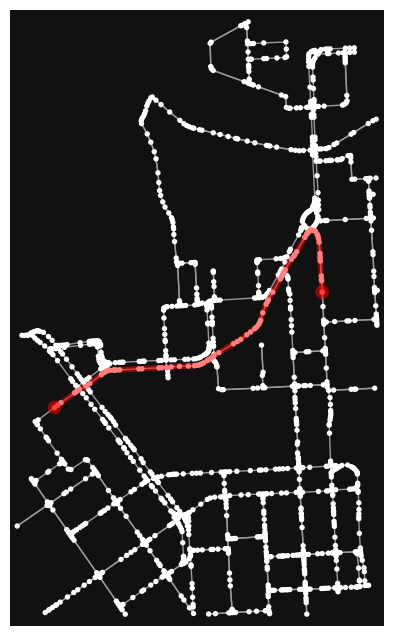

Text(0.5, 58.833333333333314, 'Shortest path distance  1127.4 meters.')

In [28]:
# Shortest path based on distance
fig, ax = ox.plot_graph_route(G, metric_path)

# Add the travel time as title
ax.set_xlabel("Shortest path distance {t: .1f} meters.".format(t=travel_length))

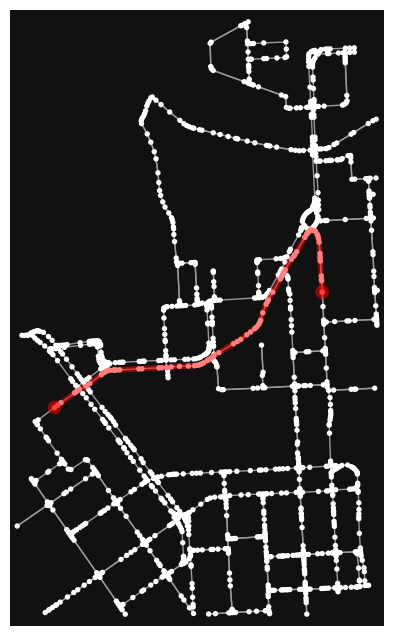

Text(0.5, 58.833333333333314, 'Travel time  1.9 minutes.')

In [29]:
fig, ax = ox.plot_graph_route(G, time_path)

# Add the travel time as title
ax.set_xlabel("Travel time {t: .1f} minutes.".format(t=travel_time/60))

Great! Now we have successfully found the optimal route between our origin and destination and we also have estimates about the travel time that it takes to travel between the locations by walking and cycling. As we can see, the route for both travel modes is exactly the same which is natural, as the only thing that changed here was the constant travel speed.

- Let's still finally see an example how you can plot a nice interactive map out of our results with OSMnx and geopandas:

In [30]:
route = ox.routing.route_to_gdf(G, time_path)
route.explore(color="red", tooltip="travel_time_seconds", style_kwds={"weight": 6})

## Compute travel time matrices between multiple locations

When trying to understand the accessibility of a specific location, you typically want to look at travel times between multiple locations (one-to-many). Next, we will learn how to calculate travel time matrices with the `cafein` Python library.

When calculating travel times with `cafein`, you typically need a couple of datasets:

- **A street network dataset from OpenStreetMap** (OSM) in Protocolbuffer Binary (`.pbf`) format:
  - This data is used for finding the fastest routes and calculating the travel times by walking, cycling and driving. In addition, `cafein` uses it for the walking legs to and from the stops when routing with public transport.
- **A transit schedule dataset** in General Transit Feed Specification (GTFS) format:
  - This data contains the information needed for routing with public transport, such as the stops, routes, trips and the times when the vehicles pass a specific stop. You can read about the [GTFS standard from here](https://gtfs.org/documentation/schedule/reference/).

### Sample datasets

In this tutorial, we use sample datasets for the Helsinki region that the `cafein.sampledata` library downloads for us: an OpenStreetMap extract, the public transport schedules of Helsinki Region Transport (HSL), and a population grid from Helsinki Region Environmental Services (HSY). You can learn more about `cafein` in Tutorial II.

### Load the origin and destination data

Let's start by reading the population grid, which contains the number of residents (`asukkaita`) of each 250 meter cell, and by converting the cells into points that we can use as our destinations:

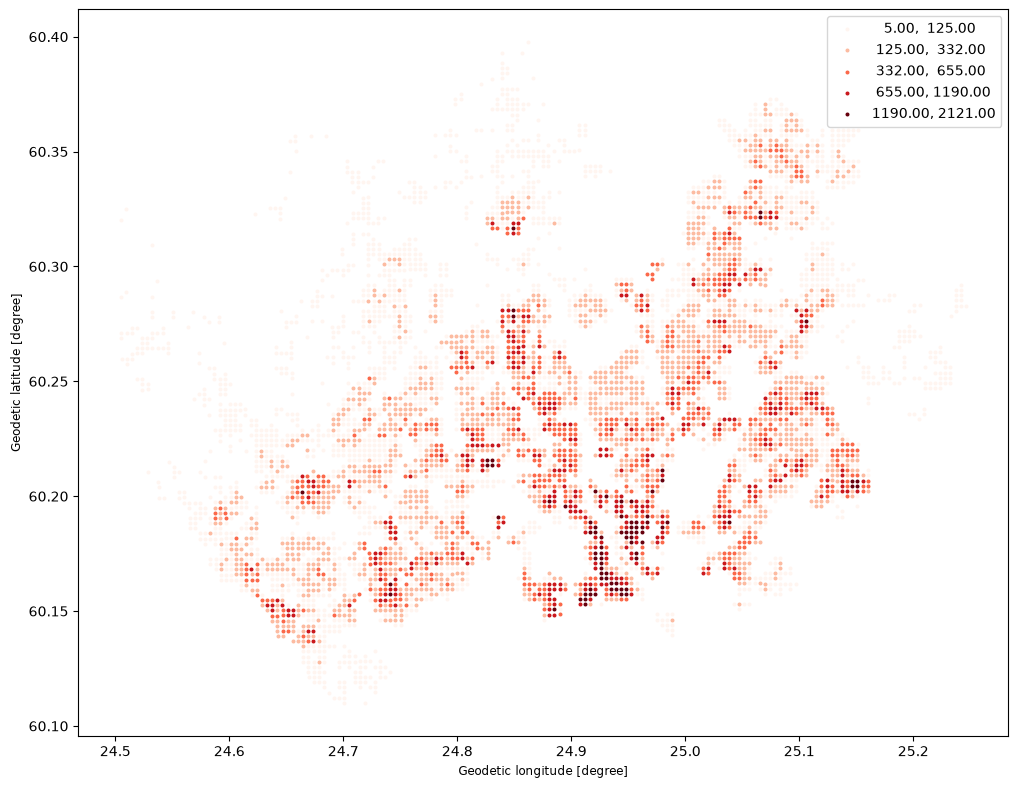

In [31]:
import geopandas as gpd
import cafein
import cafein.sampledata.helsinki as helsinki

pop_grid = gpd.read_file(helsinki.population_grid)

# Get centroids
points = pop_grid.copy()
points["geometry"] = points.centroid

# Reproject
points = points.to_crs(epsg=4326)
points.plot("asukkaita", scheme="natural_breaks", cmap="Reds", figsize=(12, 12), legend=True, markersize=3.5);

Next, we will geocode the address of Helsinki Railway Station. For doing this, we can use the `osmnx` library and its handy `.geocode()` function:

In [32]:
import osmnx as ox
from shapely.geometry import Point

# Find coordinates of the central railway station of Helsinki
lat, lon = ox.geocode("Rautatieasema, Helsinki")

# Create a GeoDataFrame out of the coordinates
station = gpd.GeoDataFrame({"geometry": [Point(lon, lat)], "name": "Helsinki Railway station", "id": ["station"]}, index=[0], crs="epsg:4326")
station.explore(max_zoom=13, color="red", marker_kwds={"radius": 12})

- Next, we will prepare the routable network from the GTFS data and the OSM extract (this takes a minute or two):

In [33]:
%%time
import datetime

transport_network = cafein.TransportNetwork.from_gtfs(helsinki.gtfs, osm_pbf=helsinki.osm_pbf)
transport_network.service_window

.../site-packages/cafein/streets.py:374: UserWarning: 1009 stop(s) are farther than 1600.0 m from the walking network and get no footpaths
  snapped = _snap_to_edges(stop_points, edges, max_snap_distance)


CPU times: user 37.3 s, sys: 3.32 s, total: 40.6 s
Wall time: 37.2 s


(datetime.date(2026, 8, 20), datetime.date(2026, 10, 18))

- After this step, we can do the routing. The departure time needs to fall inside the service window of the GTFS data, which we printed above:

In [34]:
departure = datetime.datetime(2026, 9, 1, 8, 30)
travel_time_matrix = cafein.TravelTimeMatrix(transport_network, origins=station, destinations=points, departure=departure)

In [35]:
travel_time_matrix.head()

,from_id,to_id,travel_time
0,station,Vaestotietoruudukko_2025.1,84
1,station,Vaestotietoruudukko_2025.2,133
2,station,Vaestotietoruudukko_2025.3,130
3,station,Vaestotietoruudukko_2025.4,128
4,station,Vaestotietoruudukko_2025.5,125


- Now we can join the travel time information back to the population grid

In [36]:
geo = pop_grid.merge(travel_time_matrix, left_on="id", right_on="to_id")

In [37]:
geo.head()

,id,index,asukkaita,asvaljyys,ika0_9,ika10_19,ika20_29,ika30_39,ika40_49,ika50_59,ika60_69,ika70_79,ika_yli80,paivitys_pvm,geometry,from_id,to_id,travel_time
0,Vaestotietoruudukko_2025.1,688,6,57.17,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((362054.365 6689582.191, 362061.946 6...",station,Vaestotietoruudukko_2025.1,84
1,Vaestotietoruudukko_2025.2,703,6,42.83,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((361940.674 6685834.568, 361948.252 6...",station,Vaestotietoruudukko_2025.2,133
2,Vaestotietoruudukko_2025.3,710,6,59.33,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((361887.631 6684085.685, 361895.208 6...",station,Vaestotietoruudukko_2025.3,130
3,Vaestotietoruudukko_2025.4,711,6,99.33,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((361880.054 6683835.845, 361887.631 6...",station,Vaestotietoruudukko_2025.4,128
4,Vaestotietoruudukko_2025.5,715,8,56.50,99,99,99,99,99,99,99,99,99,2026-08-05,"POLYGON ((361849.748 6682836.473, 361857.325 6...",station,Vaestotietoruudukko_2025.5,125


- Finally, we can visualize the travel time map and investigate how the railway station in Helsinki can be accessed from different parts of the region, by public transport.

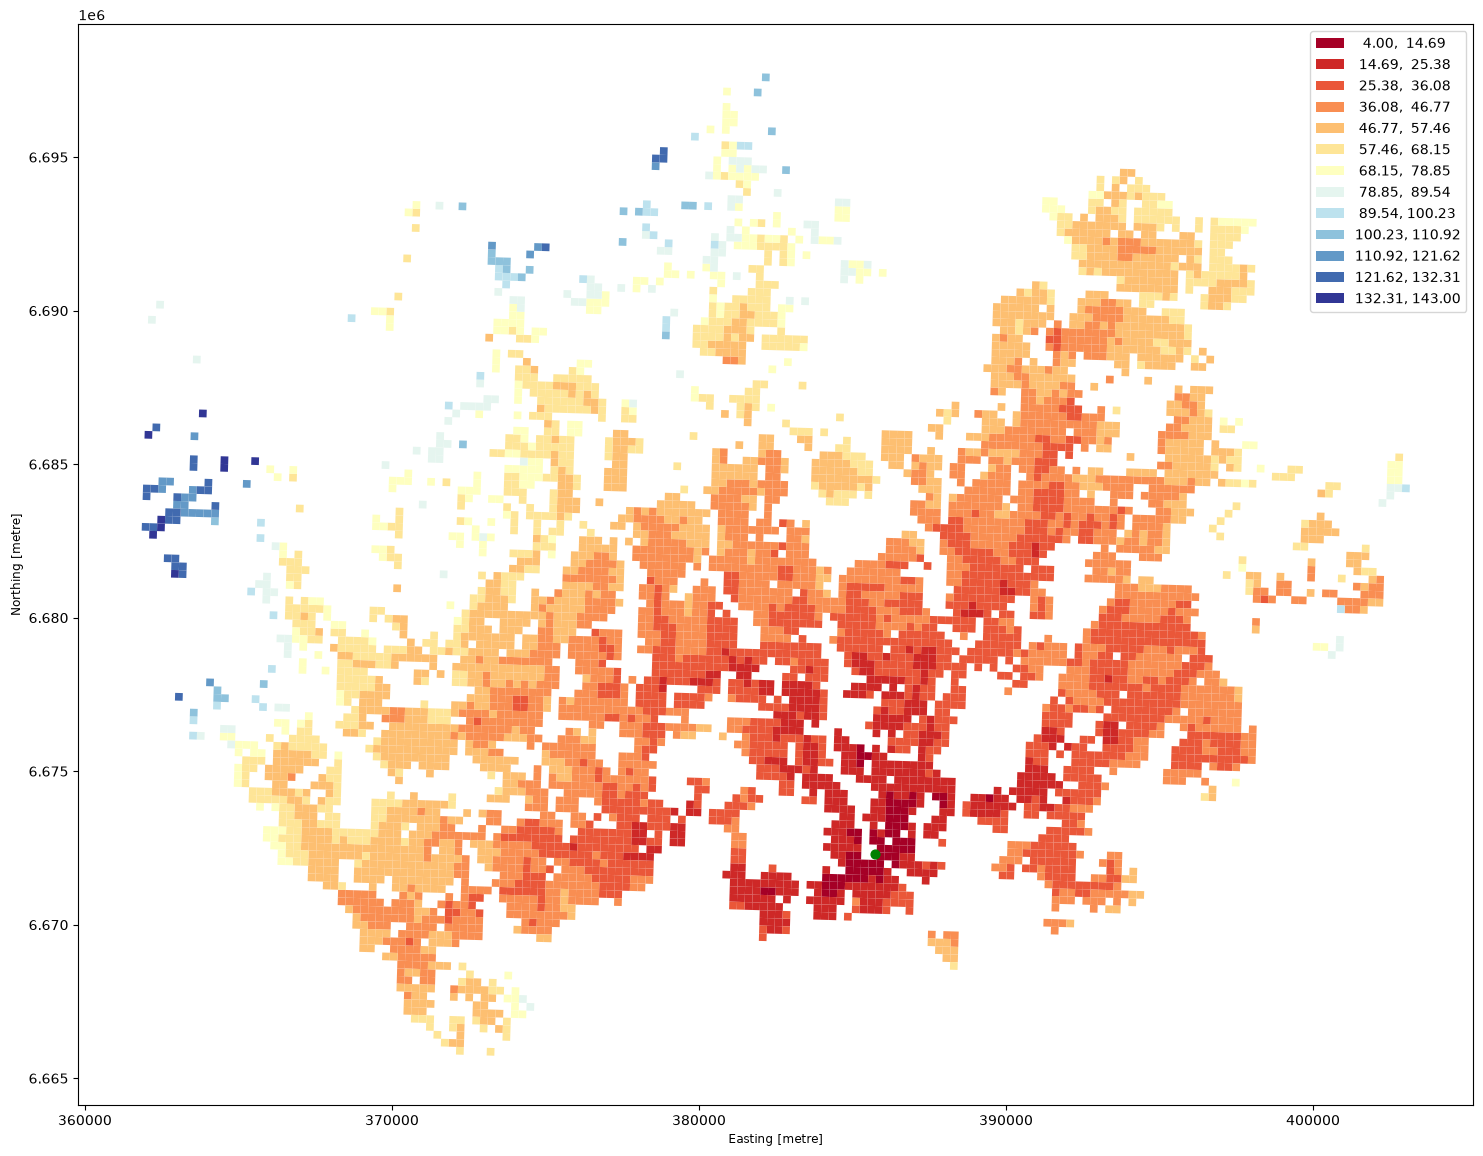

In [38]:
ax = geo.plot(column="travel_time", cmap="RdYlBu", scheme="equal_interval", k=13, legend=True, figsize=(18, 18))
ax = station.to_crs(crs=geo.crs).plot(ax=ax, color="green", markersize=40)

## Calculate travel times by bike

In a very similar manner, we can calculate travel times by cycling. For cycling, we build a `StreetNetwork` from the OSM data and tell the mode with the `transport_mode` parameter:

In [39]:
bike_network = cafein.StreetNetwork.from_osm(helsinki.osm_pbf, modes=["bicycle"])
ttm_bike = cafein.TravelTimeMatrix(bike_network, origins=station, destinations=points, transport_mode="bicycle")

- Let's again make a table join with the population grid

In [40]:
geo = pop_grid.merge(ttm_bike, left_on="id", right_on="to_id")

- And plot the data

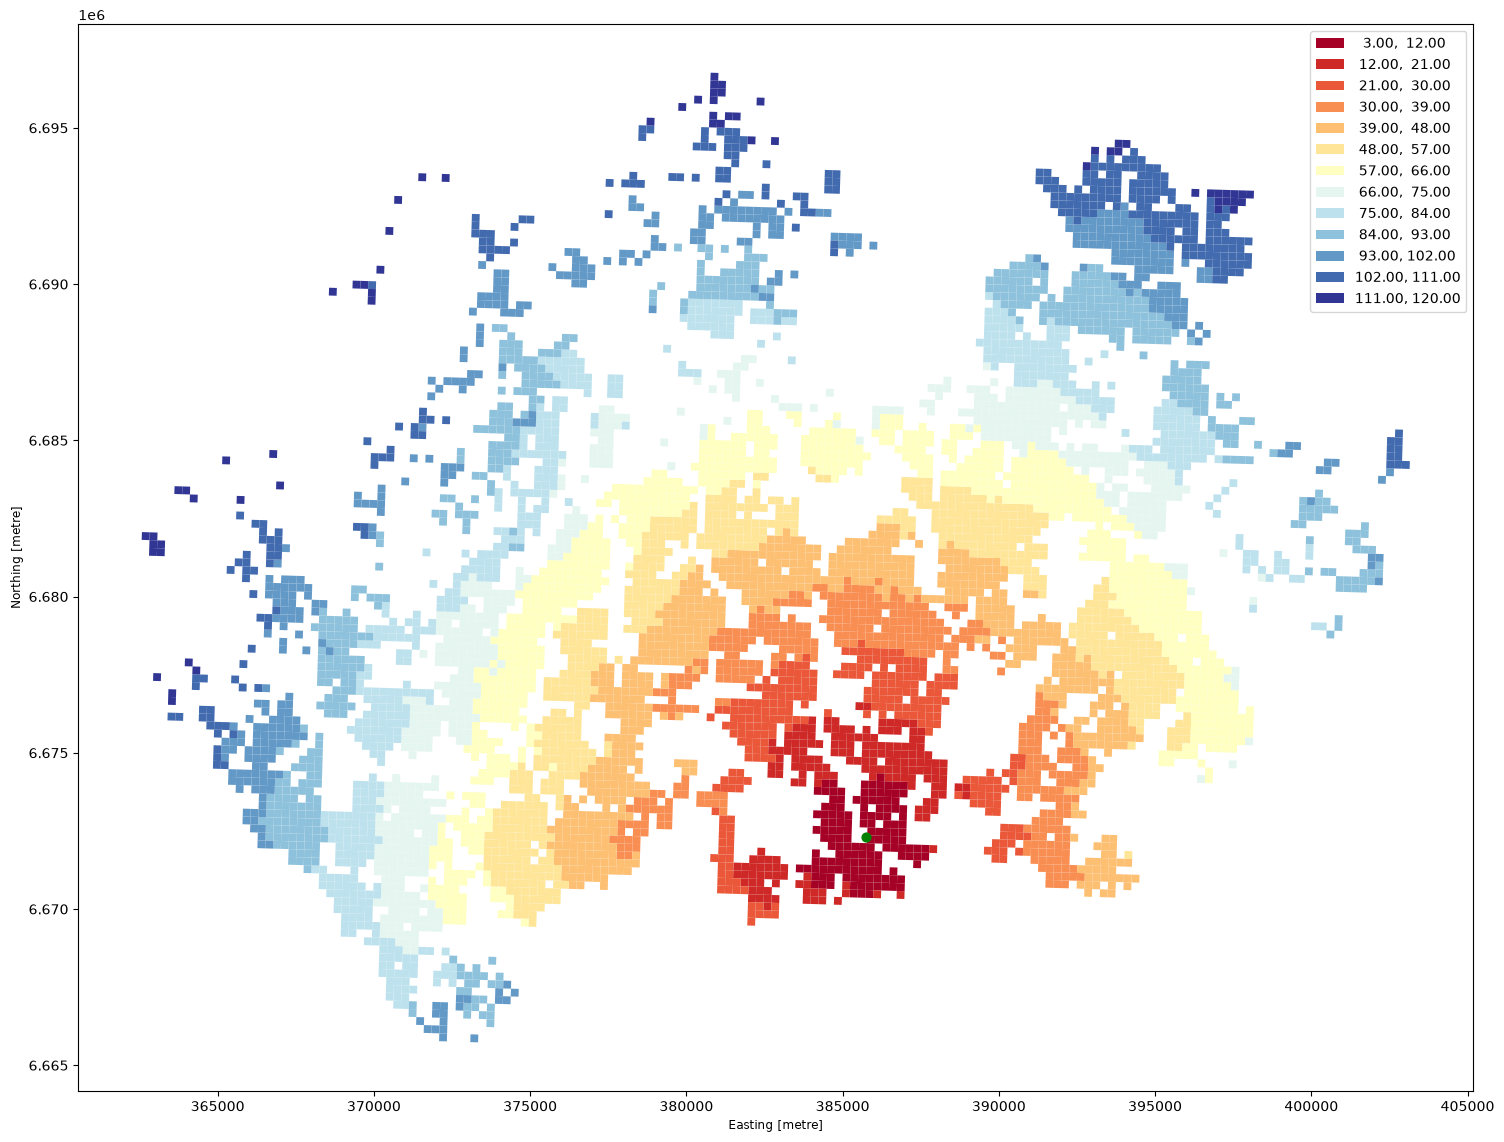

In [41]:
ax = geo.plot(column="travel_time", cmap="RdYlBu", scheme="equal_interval", k=13, legend=True, figsize=(18, 18))
ax = station.to_crs(crs=geo.crs).plot(ax=ax, color="green", markersize=40)

## Calculate catchment areas

One quite typical accessibility analysis is to find out catchment areas for multiple locations, such as libraries. In the below, we will extract all libraries in Helsinki region and calculate travel times from all grid cells to the closest one. As a result, we have catchment areas for each library.

- Let's start by parsing the libraries in Helsinki region, using `pyrosm`

In [42]:
from pyrosm import OSM

# Initialize the reader object with the OSM extract of the sample data
osm = OSM(str(helsinki.osm_pbf))

- Libraries can be parsed by using the `get_pois` -function, and passing a custom filter in which we specify that the amenity should be a library.

In [43]:
# Fetch libraries
libraries = osm.get_pois(custom_filter={"amenity": ["library"]})

- Some of the libraries might be in Polygon format, so we need to convert them into points by calculating their centroid:

In [44]:
# Convert the geometries to points
libraries["geometry"] = libraries.to_crs(epsg=3067).centroid.to_crs(epsg=4326)
libraries["id"] = libraries["id"].astype(str)
libraries.explore(color="red", marker_kwds={"radius": 6})

- Next, we can calculate the travel times from the libraries (as origins) to all grid cells:

In [45]:
travel_time_matrix = cafein.TravelTimeMatrix(transport_network, origins=libraries, destinations=points, departure=departure)

In [46]:
travel_time_matrix.shape

(588325, 3)

- As we can see, there are hundreds of thousands of rows of data, which comes as a result of all connections between origins and destinations. Next, we want to aggregate the data and keep only the travel time to the closest library:

In [47]:
# Find out the travel time to closest library
closest_library = travel_time_matrix.groupby("to_id")["travel_time"].min().reset_index()

In [48]:
closest_library

,to_id,travel_time
0,Vaestotietoruudukko_2025.1,54
1,Vaestotietoruudukko_2025.10,31
2,Vaestotietoruudukko_2025.100,36
3,Vaestotietoruudukko_2025.1000,26
4,Vaestotietoruudukko_2025.1001,27
...,...,...
5820,Vaestotietoruudukko_2025.995,28
5821,Vaestotietoruudukko_2025.996,27
5822,Vaestotietoruudukko_2025.997,27
5823,Vaestotietoruudukko_2025.998,23


Then we can make a table join with the grid in a similar manner as previously and visualize the data:

In [49]:
geo = pop_grid.merge(closest_library, left_on="id", right_on="to_id")

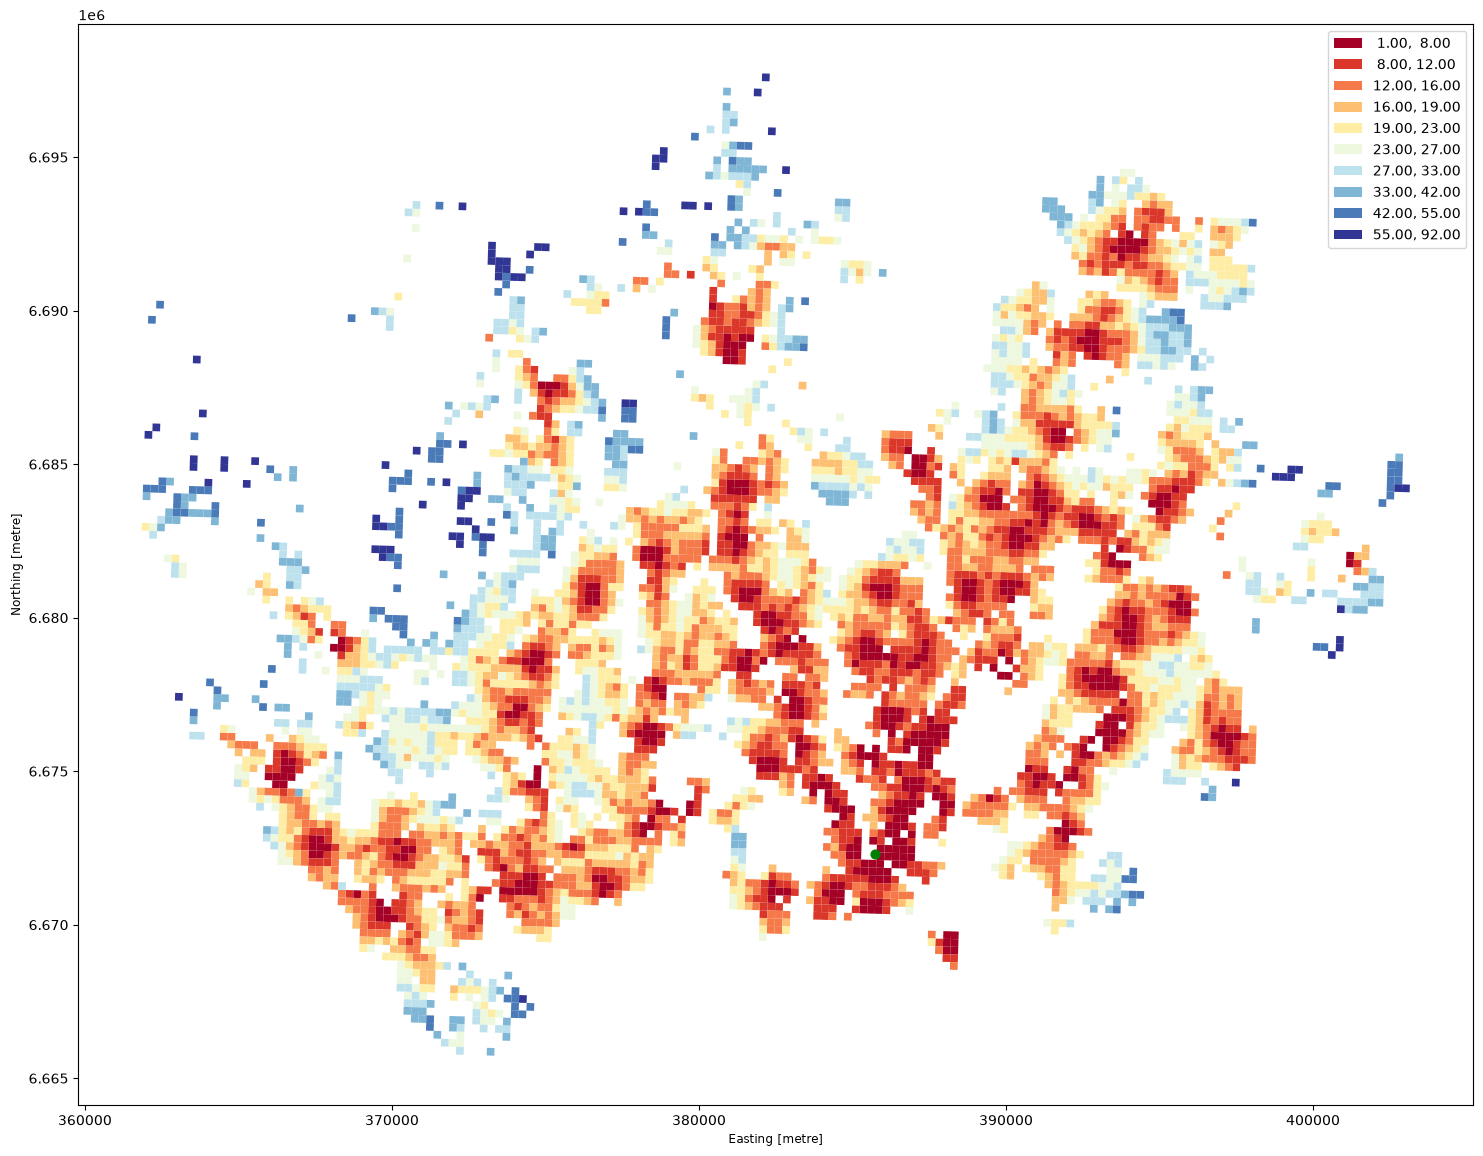

In [50]:
ax = geo.plot(column="travel_time", cmap="RdYlBu", scheme="natural_breaks", k=10, legend=True, figsize=(18, 18))
ax = station.to_crs(crs=geo.crs).plot(ax=ax, color="green", markersize=40)

That's it! As you can see, now we have a nice map showing the travel time to the closest library from each grid cell.

## Analyze accessibility

After we have calculated the travel times to the closest services, we can start analyzing accessibility. There are various ways to analyze how accessible services are. Here, for the sake of simplicity, we calculate the number of inhabitants that can reach the services within a given travel time threshold (e.g. 15 minutes) by PT (or walking).

In [51]:
# Extract the grid cells within given travel time threshold
threshold = 15
access = geo.loc[geo["travel_time"] <= threshold].copy()

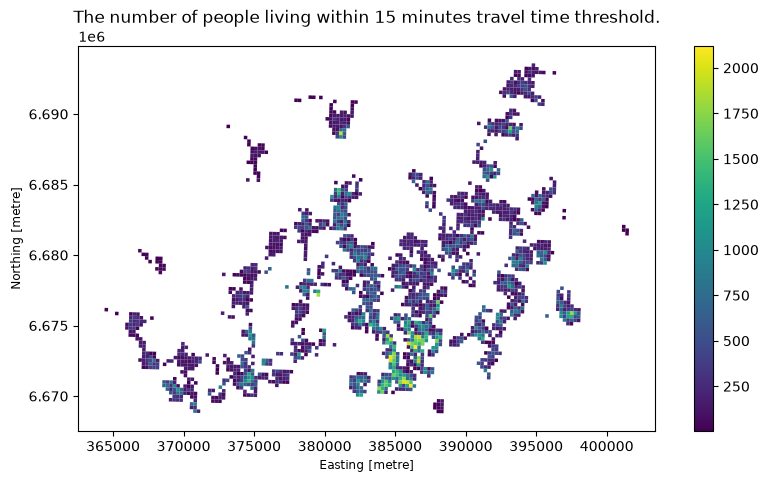

In [52]:
ax = access.plot(column="asukkaita", figsize=(10, 5), legend=True)
ax.set_title(f"The number of people living within {threshold} minutes travel time threshold.");

Now we can easily calculate how many people or what is the proportion of people that can access the given service within the given travel time threshold:

In [53]:
pop_within_threshold = access["asukkaita"].sum()
pop_share = pop_within_threshold / geo["asukkaita"].sum()
print(f"Population within accessibility thresholds: {pop_within_threshold} ({pop_share*100:.0f} %)")

Population within accessibility thresholds: 755076 (60 %)


We can see what proportion of the population in the region can access a library within the given time threshold.
With this information we can start evaluating whether the level of access for the population in the region can be considered as "sufficient" or equitable. Naturally, with more detailed data, we could start evaluating whether e.g. certain population groups have lower access than on average in the region, which enables us to start studying the questions of justice and equity. Often the interesting question is to understand "who does not have access"? I.e. who is left out.

There are many important questions relating to equity of access that require careful consideration when doing these kind of analyses, for example what is seen as a "reasonable" level of access, i.e. what we should specify as the travel time threshold in our analysis.

## Cumulative opportunities

Another commonly used approach to analyze accessibility is to analyze how many services can a given individual (or group of individuals) access within given travel time budget. This is called cumulative opportunities measure.

In [54]:
# How many services can be reached from each grid cell within given travel time threshold?
travel_time_matrix.head()

,from_id,to_id,travel_time
0,50807898,Vaestotietoruudukko_2025.1,116
1,50807898,Vaestotietoruudukko_2025.2,133
2,50807898,Vaestotietoruudukko_2025.3,130
3,50807898,Vaestotietoruudukko_2025.4,128
4,50807898,Vaestotietoruudukko_2025.5,125


In [55]:
threshold = 15
# Count the number of opportunities from each grid cell
opportunities = travel_time_matrix.loc[travel_time_matrix["travel_time"] <= threshold].groupby("to_id")["from_id"].count().reset_index()

# Rename the column for more intuitive one
opportunities = opportunities.rename(columns={"from_id": "num_opportunities"})

In [56]:
# Merge with population grid
opportunities = pop_grid.merge(opportunities, left_on="id", right_on="to_id")

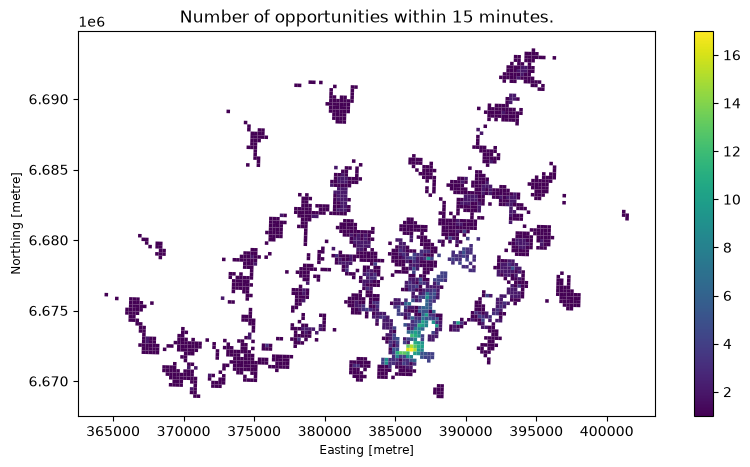

In [57]:
# Plot the results
ax = opportunities.plot(column="num_opportunities", figsize=(10, 5), legend=True)
ax.set_title(f"Number of opportunities within {threshold} minutes.");

Now we can clearly see the areas with highest level of accessibility to given service. This is called cumulative opportunities measure or "Hansen's Accessibility" measure after its developer.  

At times one could still want apply a distance decay function to give more weight to the closer services and less to the services that are further away, and hence less likely to be visited by citizens who seek to use the service. This is called as time-weighted cumulative opportunities measure. There are also many other approaches to measure accessibility which are out of scope of this tutorial. In case you are interested in understanding more, I recommend reading following papers:

- Levinson, D. & H. Wu (2020). [Towards a general theory of access.](https://www.jtlu.org/index.php/jtlu/article/view/1660)
- Wu, H. & D. Levinson (2020). [Unifying access.](https://www.sciencedirect.com/science/article/abs/pii/S1361920920305423)